In [1]:
import mesa_reader as mr
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


In [4]:
# log = mr.MesaLogDir('c:/Users/abhav/test/profiles_4')
# h5 = mr.MesaData('c:/Users/abhav/test/history_5.data')
# profile1 = mr.MesaData('c:/Users/abhav/test/profile1.data')
# h6 = mr.MesaData('c:/Users/abhav/test/history_6.data')
h1 = mr.MesaData('c:/Users/abhav/Documents/UIUC_Graduate/RESEARCH/history.data')


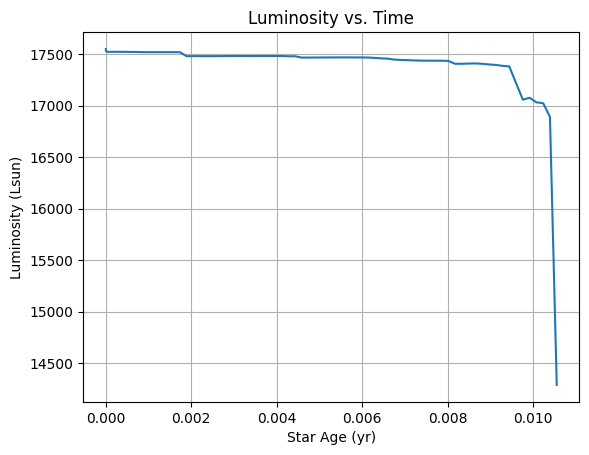

In [13]:
plt.plot(h1.star_age, 10**h1.log_L, label='Luminosity')
# plt.plot(h1.star_age, h1.aorb/Rsun)
plt.xlabel('Star Age (yr)')
plt.ylabel('Luminosity (Lsun)')
plt.title('Luminosity vs. Time')
# plt.xscale('log')
# plt.yscale('log')
plt.grid()
plt.show()
plt.close()

In [7]:
G_const = 6.67430e-8  # cm^3 g^-1 s^-2
Rsun = 6.957e10  # cm
Msun = 1.989e33  # g
clight = 2.99792458e10  # cm/s
# Mns = 1.33 * Msun  # g
sec_per_yr = 3.154e7  # s/yr
op_const = 0.1 # cm^2/g

#IGNORE THIS FUNCTION
def compute_params(history):
    f1  = 1.91791946
    f2  = -1.52814698
    f3 = 0.75992092
    mu1 = -2.14034214
    mu2 = 1.94694764
    mu3 = 1.19007536
    mu4 = 1.05762477
    eta = 1

    # Extracting necessary data from the log
    t = history.star_age
    aorb = history.aorb
    Menc = history.menc
    rho = history.rho
    P = np.exp(history.lnPgas)
    T = np.exp(history.lnT)
    renv = Rsun*10**history.log_R
    scale_height = history.scale_height
    csound = history.csound
    dt = history.time_step
    Mns = history.M_ns

    v_rel = np.sqrt(G_const * (Mns + Menc) / aorb)
    da_dEorb = ((G_const * Mns * Menc)/(2 * aorb**2) - (G_const * Mns / (2 * aorb))*(4 * np.pi * aorb**2 * rho))**(-1)
    mach = v_rel / csound

    beta = G_const * Mns / (aorb * csound**2)
    eta_b = beta/ (mach**2 - 1)
    cd = 1
    rho_nl = rho * (1 + 0.46*beta**1.1 / (mach**2 -1)**0.11)

    Ra = 2 * G_const * Mns / v_rel**2
    mdot_hl = np.pi * Ra**2 * rho * v_rel
    fd_hl = mdot_hl * v_rel
    edot_hl = fd_hl * v_rel

    mdot_edd = 3.5e-8 * (Mns / Msun) * (0.34 / op_const) * Msun / sec_per_yr
    mdot_hyper = 8.9e-5*((op_const/0.34)**(-0.73))*Msun/sec_per_yr

    eps_rho = Ra / scale_height
    fd_mr15_ratio = f1 + f2*eps_rho + f3*eps_rho**2
    mdot_mr15_ratio = 10**(mu1 + mu2/(1 + mu3*eps_rho + mu4*eps_rho**2))
    mdot_out_mr15 = eta * mdot_mr15_ratio * mdot_hl
    fd_out_mr15 = eta * fd_mr15_ratio * fd_hl

    edot_out_mr15 = np.empty(len(aorb))
    edot_out_k10 = np.empty(len(aorb))
    i_var = np.empty(len(aorb))
    fd_out_k10 = np.empty(len(aorb))
    for i in range(len(aorb)):
        if mdot_edd[i] < mdot_out_mr15[i] and mdot_out_mr15[i] < mdot_hyper:
            mdot_out_mr15[i] = mdot_edd[i]
            fd_out_mr15[i] = mdot_edd[i] * v_rel[i]
        edot_out_mr15[i] = fd_out_mr15[i] * v_rel[i]

        if mach[i] < 1.01:
            i_var[i] = 0.7706*np.log((1+mach[i])/(1.0004 - 0.9185*mach[i])) - 1.473*mach[i]
        elif mach[i] >= 1.01 and mach[i] < 4.4:
            i_var[i] = np.log(330*(aorb[i]*(mach[i]-0.71)**5.72)/(Ra[i]*mach[i]**9.58))
        else:
            i_var[i] = np.log(aorb[i] / (Ra[i]*(0.11*mach[i] + 1.65)))

        if eta_b[i] > 0.1 and mach[i] > 1.01:
            fd_out_k10[i] = cd * (4 * np.pi * rho_nl[i] * ((G_const * Mns[i] / v_rel[i])**2) ) * (0.7/eta_b[i]**0.5)
        else:
            fd_out_k10[i] = cd * (4 * np.pi * rho[i] * ((G_const * Mns[i] / v_rel[i])**2) ) * i_var[i]
        
        edot_out_k10[i] = fd_out_k10[i] * v_rel[i]

    adot_mag = edot_out_k10 * da_dEorb
    e_inj = edot_out_k10 * dt

    return t, aorb, Menc, rho, scale_height, v_rel, csound, mach, mdot_out_mr15, edot_out_k10, fd_out_k10, adot_mag, e_inj

def drag_and_accretion(aorb, M_ns, v_rel, csound, scale_height, rho):
    f1  = 1.91791946
    f2  = -1.52814698
    f3 = 0.75992092
    mu1 = -2.14034214
    mu2 = 1.94694764
    mu3 = 1.19007536
    mu4 = 1.05762477

    Ra = 2 * G_const * M_ns / v_rel**2
    mdot_hl = np.pi * Ra**2 * rho * v_rel
    fd_hl = mdot_hl * v_rel
    # edot_hl = fd_hl * v_rel
    mach = v_rel / csound
    # print('mach = ' + str(mach))
    beta = G_const * M_ns / (aorb * csound**2)
    eta_b = beta/ (mach**2 - 1)
    cd = 1
    rho_nl = rho * (1 + 0.46*(beta**1.1) / (mach**2 - 1)**0.11)
    # print('eta_b = ' + str(eta_b))

    eps_rho = Ra / scale_height
    fd_mr15_ratio = f1 + f2*eps_rho + f3*eps_rho**2
    mdot_mr15_ratio = 10**(mu1 + mu2/(1 + mu3*eps_rho + mu4*eps_rho**2))
    mdot_out_mr15 = mdot_mr15_ratio * mdot_hl
    fd_out_mr15 = fd_mr15_ratio * fd_hl

    if mach < 1.01:
        # print('a')
        i_var = 0.7706*np.log((1+mach)/(1.0004 - 0.9185*mach)) - 1.473*mach
    elif mach >= 1.01 and mach < 4.4:
        # print('b')
        i_var = np.log(330*(aorb*(mach-0.71)**5.72)/(Ra*mach**9.58))
    else:
        # print('c')
        i_var = np.log(aorb / (Ra*(0.11*mach + 1.65)))  

    # print('ivar = ' + str(i_var))
    
    if eta_b > 0.1 and mach > 1.01:
        # print('d')
        fd_out_k10 = cd * (4 * np.pi * rho_nl * ((G_const * M_ns / v_rel)**2) ) * (0.7/eta_b**0.5)
    else:
        # print('e')
        fd_out_k10 = cd * (4 * np.pi * rho * ((G_const * M_ns / v_rel)**2) ) * i_var
    # edot_out_k10 = fd_out_k10 * v_rel   

    # print('fd_k10 = {:.2e} g cm/s^2, fd_mr15 = {:.2e} g cm/s^2, mdot_mr15 = {:.2e} g/s'.format(fd_out_k10, fd_out_mr15, mdot_out_mr15))
    return fd_out_k10, fd_out_mr15, mdot_out_mr15

def elliptical_orbit(profile, ainitial, dt = 1e5, M_ns_initial = 1.33*Msun, omega_ratio = 0):

    #initial values
    fmass = interp1d(profile.logR, profile.mass, kind = 'cubic', fill_value = 'extrapolate')
    fcsound = interp1d(profile.logR, profile.csound, kind = 'linear', fill_value = 'extrapolate')
    frho = interp1d(profile.logR, profile.logRho, kind = 'linear', fill_value = 'extrapolate')
    fscale_height = interp1d(profile.logR, profile.scale_height, kind = 'linear', fill_value = 'extrapolate')

    menc_initial = fmass(np.log10(ainitial/Rsun)) * Msun
    csound_initial = fcsound(np.log10(ainitial/Rsun))
    rho_initial = 10**frho(np.log10(ainitial/Rsun))
    scale_height_initial = fscale_height(np.log10(ainitial/Rsun)) * Rsun
    omega_env = omega_ratio * np.sqrt(G_const * (M_ns_initial + menc_initial) / ainitial**3)

    #checking interpolation
    print('menc_initial = ' + str(menc_initial), '   menc at surface: ' + str(profile.mass[0]*Msun))
    print('csound_initial = ' + str(csound_initial), '   csound at surface: ' + str(profile.csound[0]))
    print('rho_initial = ' + str(rho_initial), '   rho at surface: ' + str(10**profile.logRho[0]))
    print('scale_height_initial = ' + str(scale_height_initial), '   scale height at surface: ' + str(Rsun*profile.scale_height[0]))

    #arrays to store values
    t = np.array([])
    xcore = np.array([])
    ycore = np.array([])
    xcomp = np.array([])
    ycomp = np.array([])
    vxcore = np.array([])
    vycore = np.array([])
    vxcomp = np.array([])
    vycomp = np.array([])
    aorb = np.array([])
    vx_rel = np.array([])
    vy_rel = np.array([])
    v_rel = np.array([])
    M_ns = np.array([])
    csound = np.array([])
    scale_height = np.array([])
    rho = np.array([])
    fd_mr15 = np.array([])
    fd_k10 = np.array([])
    mdot_mr15 = np.array([])

    #initial conditions
    t = np.append(t, 0)
    xcore = np.append(xcore, 0)
    ycore = np.append(ycore, 0)
    xcomp = np.append(xcomp, ainitial)
    ycomp = np.append(ycomp, 0)
    vxcore = np.append(vxcore, 0)
    vycore = np.append(vycore, 0)
    vxcomp = np.append(vxcomp, 0)
    vycomp = np.append(vycomp, np.sqrt(G_const * (M_ns_initial + menc_initial) / ainitial))
    aorb = np.append(aorb, ainitial)
    M_ns = np.append(M_ns, M_ns_initial) #right now i am keeping it constant, but it should be updated based on accretion
    csound = np.append(csound, csound_initial)
    scale_height = np.append(scale_height, scale_height_initial)
    rho = np.append(rho, rho_initial)
    vx_rel = np.append(vx_rel, 0)
    vy_rel = np.append(vy_rel, np.sqrt(G_const * (M_ns_initial + menc_initial) / ainitial) - omega_env * ainitial)
    v_rel = np.append(v_rel, np.sqrt(vx_rel[-1]**2 + vy_rel[-1]**2))
    temp1, temp2, temp3 = drag_and_accretion(ainitial, M_ns_initial, v_rel[-1], csound[-1], scale_height[-1], rho[-1])
    fd_k10 = np.append(fd_k10, temp1)
    fd_mr15 = np.append(fd_mr15, temp2)
    mdot_mr15 = np.append(mdot_mr15, temp3)

    #printing initial values
    print('xcore = {:.2e} cm, ycore = {:.2e} cm, vxcore = {:.2e} cm/s, vycore = {:.2e} cm/s'.format(xcore[-1], ycore[-1], vxcore[-1], vycore[-1]))
    print('xcomp = {:.2e} cm, ycomp = {:.2e} cm, vxcomp = {:.2e} cm/s, vycomp = {:.2e} cm/s'.format(xcomp[-1], ycomp[-1], vxcomp[-1], vycomp[-1]))
    print('vx_rel = {:.2e} cm/s, vy_rel = {:.2e} cm/s, v_rel = {:.2e} cm/s'.format(vx_rel[-1], vy_rel[-1], v_rel[-1]))
    print('aorb = {:.2e} cm, M_ns = {:.2e} g, csound = {:.2e} cm/s, scale_height = {:.2e} cm, rho = {:.2e} g/cm^3'.format(aorb[-1], M_ns[-1], csound[-1], scale_height[-1], rho[-1]))
    # print('fd_k10 = {:.2e} g cm/s^2, fd_mr15 = {:.2e} g cm/s^2, mdot_mr15 = {:.2e} g/s'.format(fd_k10[-1], fd_mr15[-1], mdot_mr15[-1]))

    i = 0
    while i < 100000 and aorb[-1] > Rsun*10**profile.logR[-1]:
    
        dxdt = np.empty(8)

        #rate of change calculations
        dxdt[4] = G_const * M_ns[-1] * (xcomp[-1] - xcore[-1]) / aorb[-1]**3
        dxdt[5] = G_const * M_ns[-1] * (ycomp[-1] - ycore[-1]) / aorb[-1]**3
        dxdt[6] = G_const * (fmass(np.log10(aorb[-1]/Rsun)) * Msun) * (xcore[-1] - xcomp[-1]) / aorb[-1]**3 - fd_k10[-1] * vx_rel[-1] / (M_ns[-1] * v_rel[-1])
        dxdt[7] = G_const * (fmass(np.log10(aorb[-1]/Rsun)) * Msun) * (ycore[-1] - ycomp[-1]) / aorb[-1]**3 - fd_k10[-1] * vy_rel[-1] / (M_ns[-1] * v_rel[-1])

        #forward euler update
        t = np.append(t, t[-1] + dt)

        vxcore = np.append(vxcore, vxcore[-1] + dxdt[4]*dt)
        vycore = np.append(vycore, vycore[-1] + dxdt[5]*dt)
        vxcomp = np.append(vxcomp, vxcomp[-1] + dxdt[6]*dt)
        vycomp = np.append(vycomp, vycomp[-1] + dxdt[7]*dt)

        dxdt[0] = vxcore[-1]
        dxdt[1] = vycore[-1]
        dxdt[2] = vxcomp[-1]
        dxdt[3] = vycomp[-1]

        xcore = np.append(xcore, xcore[-1] + dxdt[0]*dt)
        ycore = np.append(ycore, ycore[-1] + dxdt[1]*dt)
        xcomp = np.append(xcomp, xcomp[-1] + dxdt[2]*dt)
        ycomp = np.append(ycomp, ycomp[-1] + dxdt[3]*dt)

        #updating other parameters
        aorb = np.append(aorb, np.sqrt((xcomp[-1] - xcore[-1])**2 + (ycomp[-1] - ycore[-1])**2))
        M_ns = np.append(M_ns, M_ns_initial) #mdot_mr15[-1]*dt)
        csound = np.append(csound, fcsound(np.log10(aorb[-1]/Rsun)))
        vx_rel = np.append(vx_rel, vxcomp[-1] - vxcore[-1] + omega_env * (ycomp[-1] - ycore[-1]))
        vy_rel = np.append(vy_rel, vycomp[-1] - vycore[-1] - omega_env * (xcomp[-1] - xcore[-1]))
        v_rel = np.append(v_rel, np.sqrt(vx_rel[-1]**2 + vy_rel[-1]**2))
        scale_height = np.append(scale_height, fscale_height(np.log10(aorb[-1]/Rsun)) * Rsun)
        rho = np.append(rho, 10**frho(np.log10(aorb[-1]/Rsun)))
        temp1, temp2, temp3 = drag_and_accretion(aorb[-1], M_ns[-1], v_rel[-1], csound[-1], scale_height[-1], rho[-1])
        fd_k10 = np.append(fd_k10, temp1)
        fd_mr15 = np.append(fd_mr15, temp2)
        mdot_mr15 = np.append(mdot_mr15, temp3)

        if aorb[-1] < Rsun*10**profile.logR[-1]:
            print('Warning: Orbit has entered the core')

        i += 1
        print(i)

    return t, xcore, ycore, xcomp, ycomp, vxcore, vycore, vxcomp, vycomp, aorb, vx_rel, vy_rel, v_rel, M_ns, csound, scale_height, rho, fd_mr15, fd_k10, mdot_mr15

def circular_orbit(profile, ainitial, dt = 1e5, M_ns_initial = 1.33*Msun, omega_ratio = 0):

    #initial values
    fmass = interp1d(profile.logR, profile.mass, kind = 'cubic', fill_value = 'extrapolate')
    fcsound = interp1d(profile.logR, profile.csound, kind = 'linear', fill_value = 'extrapolate')
    frho = interp1d(profile.logR, profile.logRho, kind = 'linear', fill_value = 'extrapolate')
    fscale_height = interp1d(profile.logR, profile.scale_height, kind = 'linear', fill_value = 'extrapolate')

    menc_initial = fmass(np.log10(ainitial/Rsun)) * Msun
    csound_initial = fcsound(np.log10(ainitial/Rsun))
    rho_initial = 10**frho(np.log10(ainitial/Rsun))
    scale_height_initial = fscale_height(np.log10(ainitial/Rsun)) * Rsun
    omega_env = omega_ratio * np.sqrt(G_const * (M_ns_initial + menc_initial) / ainitial**3)

    #checking interpolation
    print('menc_initial = ' + str(menc_initial), '   menc at surface: ' + str(profile.mass[0]*Msun))
    print('csound_initial = ' + str(csound_initial), '   csound at surface: ' + str(profile.csound[0]))
    print('rho_initial = ' + str(rho_initial), '   rho at surface: ' + str(10**profile.logRho[0]))
    print('scale_height_initial = ' + str(scale_height_initial), '   scale height at surface: ' + str(Rsun*profile.scale_height[0]))

    #arrays to store values
    t = np.array([])
    aorb = np.array([])
    v_rel = np.array([])
    M_ns = np.array([])
    csound = np.array([])
    scale_height = np.array([])
    rho = np.array([])
    fd_mr15 = np.array([])
    fd_k10 = np.array([])
    mdot_mr15 = np.array([])
    
    #initial conditions
    t = np.append(t, 0)
    aorb = np.append(aorb, ainitial)
    M_ns = np.append(M_ns, M_ns_initial) #right now i am keeping
    csound = np.append(csound, csound_initial)
    scale_height = np.append(scale_height, scale_height_initial)
    rho = np.append(rho, rho_initial)
    v_rel = np.append(v_rel, np.sqrt(G_const * (M_ns_initial + menc_initial) / ainitial) - omega_env * ainitial)
    temp1, temp2, temp3 = drag_and_accretion(ainitial, M_ns_initial, v_rel[-1], csound[-1], scale_height[-1], rho[-1])
    fd_k10 = np.append(fd_k10, temp1)
    fd_mr15 = np.append(fd_mr15, temp2)
    mdot_mr15 = np.append(mdot_mr15, temp3)

    #printing initial values
    print('aorb = {:.2e} cm, M_ns = {:.2e} g, csound = {:.2e} cm/s, scale_height = {:.2e} cm, rho = {:.2e} g/cm^3'.format(aorb[-1], M_ns[-1], csound[-1], scale_height[-1], rho[-1]))
    print('v_rel = {:.2e} cm/s'.format(v_rel[-1]))
    print('fd_k10 = {:.2e} g cm/s^2, fd_mr15 = {:.2e} g cm/s^2, mdot_mr15 = {:.2e} g/s'.format(fd_k10[-1], fd_mr15[-1], mdot_mr15[-1]))

    i = 0
    while aorb[-1] > Rsun*10**profile.logR[-1]:
    
        da_dEorb = ((G_const * M_ns[-1] * fmass(np.log10(aorb[-1]/Rsun)) * Msun)/(2 * aorb[-1]**2) - (G_const * M_ns[-1] / (2 * aorb[-1]))*(4 * np.pi * aorb[-1]**2 * rho[-1]))**(-1)
        edot = fd_k10[-1] * v_rel[-1]
        adot_mag = edot * da_dEorb

        t = np.append(t, t[-1] + dt)
        aorb = np.append(aorb, aorb[-1] - adot_mag*dt)
        M_ns = np.append(M_ns, M_ns_initial) #mdot_mr15[-1]*dt)
        csound = np.append(csound, fcsound(np.log10(aorb[-1]/Rsun)))
        scale_height = np.append(scale_height, fscale_height(np.log10(aorb[-1]/Rsun)) * Rsun)
        rho = np.append(rho, 10**frho(np.log10(aorb[-1]/Rsun)))
        v_rel = np.append(v_rel, np.sqrt(G_const * (M_ns[-1] + fmass(np.log10(aorb[-1]/Rsun)) * Msun) / aorb[-1]) - omega_env * aorb[-1])
        temp1, temp2, temp3 = drag_and_accretion(aorb[-1], M_ns[-1], v_rel[-1], csound[-1], scale_height[-1], rho[-1])
        fd_k10 = np.append(fd_k10, temp1)
        fd_mr15 = np.append(fd_mr15, temp2)
        mdot_mr15 = np.append(mdot_mr15, temp3)

        if aorb[-1] < Rsun*10**profile.logR[-1]:
            print('Warning: Orbit has entered the core')

        i += 1
        print(i)    

    return t, aorb, v_rel, M_ns, csound, scale_height, rho, fd_mr15, fd_k10, mdot_mr15

In [ ]:
t, aorb, v_rel, M_ns, csound, scale_height, rho, fd_mr15, fd_k10, mdot_mr15 = circular_orbit(profile1, ainitial = 0.98*Rsun*10**profile1.logR[0], dt = 1e3, M_ns_initial = 1.33*Msun, omega_ratio = 0)

In [ ]:
plt.plot(t, aorb/Rsun)
# plt.xlim(509000, 509750)
# plt.ylim(0, 5)
# plt.xscale('log')

In [ ]:
t, xcore, ycore, xcomp, ycomp, vxcore, vycore, vxcomp, vycomp, aorb, vx_rel, vy_rel, v_rel, M_ns, csound, scale_height, rho, fd_mr15, fd_k10, mdot_mr15 = elliptical_orbit(profile1, 0.98*Rsun*10**profile1.logR[0], dt = 2e2, M_ns_initial = 1.33*Msun, omega_ratio = 0)

In [ ]:
plt.plot(t/sec_per_yr, aorb/Rsun, label = 'K10: Elliptical Orbit')
plt.xlabel('Time (yr)')
plt.ylabel('Orbital Separation (Rsun)')
plt.title('Orbital Separation vs Time')
# plt.ylim(260, 264)
# plt.xlim(0, 0.02)
# plt.yscale('log')
plt.legend()
plt.grid()
plt.show()
plt.close()

In [ ]:
t, aorb, Menc, rho, scale_height, v_rel, csound, mach, mdot_out, edot_out_k10, fd_out_k10, adot_mag, e_inj = compute_params(h5)
t6, aorb6, Menc6, rho6, scale_height6, v_rel6, csound6, mach6, mdot_out6, edot_out_k10_6, fd_out_k10_6, adot_mag6, e_inj6 = compute_params(h6)

In [ ]:
plt.plot(10**profile1.logR, profile1.logRho, label='Density Profile')
plt.xlim(260, 265)
plt.ylim(-10, -8)

In [ ]:
plt.figure(figsize=(10, 6))
# plt.plot(t, aorb/Rsun, label='Orbital Separation (Rsun)')
plt.plot(h5.star_age, h5.aorb/Rsun, label='Orbital Separation (Rsun)')
plt.plot(h5.star_age, 10**h5.log_R, label='Stellar Radius (Rsun)')
plt.xlabel('Time (s)')
plt.ylabel('Orbital Separation (Rsun)')
plt.title('Orbital Separation vs Time')
# plt.ylim(260, 265)
# plt.xlim(0, 0.01)
# plt.yscale('log')
# plt.xscale('log')
plt.legend()
plt.grid()
plt.show()
plt.close()

In [ ]:
print(h5.csound)

In [ ]:
plt.figure(figsize=(10, 6))
v_rel = np.sqrt(G_const * (h5.M_ns + h5.menc) / h5.aorb)
plt.plot(h5.star_age, h5.csound, label='Mach Number')

In [ ]:
plt.plot(t, fd_out_k10, label='Drag Force (g cm/s^2)')